# Ablation $L_{top}$ — Qwen3-Embedding-0.6B → MiniLM-L6-H384

Notebook này rút gọn harness của `main_tables.ipynb` thành một thí nghiệm paired, single-variable:

| Variant | Objective |
| --- | --- |
| `end_ctr` | $L_{end} + L_{ctr}$ |
| `end_ctr_topo` | $L_{end} + L_{ctr} + \lambda_{top}L_{top}$ |

Mỗi variant chạy với đúng ba seed `42, 43, 44`. Trong từng seed, mọi thứ ngoài `lambda_topo` đều giống nhau: corpus, thứ tự/data-loader seed, student initialization, PCA + Procrustes teacher interface, optimizer, lịch train và evaluation. Hai arm được chạy liền nhau theo từng seed để giảm temporal confound.

## Câu hỏi và metric

1. Gain downstream có lặp lại ở cả ba seed không? Báo cáo paired delta của `avg_all` (kèm `avg_iod`, `avg_ood`) theo từng seed, mean ± std và số seed có đúng dấu.
2. $L_{top}$ có thay đổi intended geometry không?
   - $W_2(H_0^T,H_0^S)$: **thấp hơn tốt hơn**. Notebook dùng đúng ground metric `chord` và cùng định nghĩa sorted finite death times/MST như loss train:
     $\sqrt{\frac{1}{n-1}\sum_i(d^S_{(i)}-d^T_{(i)})^2}$.
   - `kNN@10`: mean fraction teacher neighbours được student giữ lại, **cao hơn tốt hơn**.
   - $\rho_{Gram}$: Pearson correlation giữa các phần tử off-diagonal của cosine Gram teacher/student, **cao hơn tốt hơn**.

Probe và mọi subset metric được cố định trước, dùng chung cho cả sáu run. Với chỉ ba paired seeds, notebook ưu tiên dấu và độ lớn của effect; không diễn giải p-value như bằng chứng kết luận. Chuỗi bằng chứng mong đợi là `W2 ↓`, `kNN@10 ↑`, `rho_Gram ↑`, rồi `avg_all ↑`.


In [1]:
# 1. Cấu hình — mặc định bám setup Qwen → MiniLM của main_tables.ipynb.
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo

REPO_URL = "https://github.com/duncan-nguyen/embedding-kd.git"

PAIR = "qwen3_0.6b_to_minilm_h384"
TEACHER_MODEL = "Qwen/Qwen3-Embedding-0.6B"
STUDENT_MODEL = "nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base"
TEACHER_POOLING = "last_token"
STUDENT_POOLING = "cls"
TRAIN_DATA_REL = Path("data/train_set/train_100k.csv")
DATASET_TAG = "100k"

SEEDS = [42, 43, 44]
VARIANTS = {
    "end_ctr": {"lambda_topo": 0.0, "label": r"$L_{end}+L_{ctr}$"},
    "end_ctr_topo": {"lambda_topo": 0.3, "label": r"$L_{end}+L_{ctr}+L_{top}$"},
}

# Hyperparameters của dòng GeoODE trong main table; chỉ lambda_topo đổi giữa hai arm.
HP = {
    "batch_size": 64,
    "epochs": 5,
    "learning_rate": 7e-5,
    "max_length": 256,
    "lambda_end": 1.0,
    "lambda_ctr": 0.5,
    "topo_metric": "chord",
}
NUM_WORKERS = 2
CUDA_VISIBLE_DEVICES = "0"
STOP_ON_ERROR = True

# Bám evaluation setting hiện tại của main table. EVAL_EVERY=0 nghĩa là chỉ chấm
# downstream ở cuối train; pair threshold vẫn được calibrate trên test như main table.
# Để có test held-out chặt hơn, đặt False trước khi bắt đầu một RUN_NAME mới.
EVAL_ON_TEST_EACH_EPOCH = True
PAIR_THRESHOLD_SOURCE = "test" if EVAL_ON_TEST_EACH_EPOCH else "validation"
EVAL_EVERY = 0
EVAL_RETRIEVAL = False

# Probe cố định cho geometry: corpus sample + toàn bộ câu trong test task, không retrieval.
PROBE_SEED = 0
PROBE_CORPUS_SENTENCES = 4096
PROBE_EVAL_SPLITS = ("test_set",)
PROBE_CORE_EVAL = 4096
PROBE_BATCH_SIZE = 256
PROBE_MAX_LENGTH = HP["max_length"]

# H0 đắt O(N^2), nên lấy ba draw cố định; kNN và Gram dùng subset cố định lớn hơn.
H0_ROWS = 2000
H0_DRAWS = 3
KNN_ROWS = 4000
KNN_K = 10
GRAM_ROWS = 2000
GEOMETRY_SEED = 2026

SAVE_TO_GOOGLE_DRIVE = False
MAKE_LIGHT_ARCHIVE = True
RUN_STAMP = datetime.now(ZoneInfo("Asia/Ho_Chi_Minh")).strftime("%Y%m%d-%H%M%S")
RUN_NAME = f"topo_ablation_{PAIR}_{DATASET_TAG}_{RUN_STAMP}"
# Đặt RUN_NAME thành tên run cũ để resume/phân tích lại. Không đổi config trong cùng RUN_NAME.

assert len(SEEDS) == 3 and len(set(SEEDS)) == 3
assert VARIANTS["end_ctr"]["lambda_topo"] == 0.0
assert VARIANTS["end_ctr_topo"]["lambda_topo"] > 0.0
print(f"Pair: {TEACHER_MODEL} -> {STUDENT_MODEL}")
print(f"Seeds: {SEEDS}; variants: {list(VARIANTS)}; HP: {HP}")
print(f"Run: {RUN_NAME}")

Pair: Qwen/Qwen3-Embedding-0.6B -> nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base
Seeds: [42, 43, 44]; variants: ['end_ctr', 'end_ctr_topo']; HP: {'batch_size': 64, 'epochs': 5, 'learning_rate': 7e-05, 'max_length': 256, 'lambda_end': 1.0, 'lambda_ctr': 0.5, 'topo_metric': 'chord'}
Run: topo_ablation_qwen3_0.6b_to_minilm_h384_100k_20260831-003049


In [2]:
# 2. Dùng repo hiện tại nếu notebook nằm trong repo; nếu không thì clone.
import subprocess
import sys

cwd = Path.cwd().resolve()
PROJECT_DIR = next(
    (p for p in (cwd, *cwd.parents) if (p / "main.py").is_file() and (p / "distiller.py").is_file()),
    None,
)
if PROJECT_DIR is None:
    clone_parent = Path("/content") if Path("/content").is_dir() else cwd
    PROJECT_DIR = clone_parent / "embedding-kd"
    if PROJECT_DIR.exists():
        assert (PROJECT_DIR / "main.py").is_file(), f"Không phải repo hợp lệ: {PROJECT_DIR}"
        print(f"Reuse existing clone: {PROJECT_DIR}")
    else:
        subprocess.run(["git", "clone", REPO_URL, str(PROJECT_DIR)], check=True)

assert (PROJECT_DIR / ".git").exists(), f"Không phải Git clone: {PROJECT_DIR}"
head_before = subprocess.run(
    ["git", "-C", str(PROJECT_DIR), "rev-parse", "--short", "HEAD"],
    check=True, capture_output=True, text=True,
).stdout.strip()
subprocess.run(["git", "-C", str(PROJECT_DIR), "pull", "--ff-only"], check=True)
head_after = subprocess.run(
    ["git", "-C", str(PROJECT_DIR), "rev-parse", "--short", "HEAD"],
    check=True, capture_output=True, text=True,
).stdout.strip()
print(f"Git HEAD: {head_before} -> {head_after}")

assert (PROJECT_DIR / "requirements.txt").is_file()
print(f"Project directory: {PROJECT_DIR}")
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(PROJECT_DIR / "requirements.txt")],
    check=True,
)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
print("Dependencies installed.")

Reuse existing clone: /content/embedding-kd
Project directory: /content/embedding-kd
Dependencies installed.


In [3]:
# 3. Output, GPU/data checks và probe set cố định dùng chung cho sáu run.
import json
import os

import pandas as pd
import torch

from src.probe_set import build_probe_set, probe_digest

try:
    from google.colab import drive as colab_drive
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB and SAVE_TO_GOOGLE_DRIVE:
    colab_drive.mount("/content/drive")
    OUTPUT_BASE = Path("/content/drive/MyDrive/embedding-kd-runs")
else:
    OUTPUT_BASE = PROJECT_DIR / "runs"

RUN_ROOT = OUTPUT_BASE / RUN_NAME
ARMS_ROOT = RUN_ROOT / "arms"
CACHE_DIR = OUTPUT_BASE / "teacher_cache"
TRAIN_DATA = PROJECT_DIR / TRAIN_DATA_REL

assert TRAIN_DATA.is_file(), f"Thiếu training corpus: {TRAIN_DATA}"
for split in ("train_set", "val_set", "test_set"):
    split_dir = PROJECT_DIR / "data" / split
    assert split_dir.is_dir() and any(split_dir.glob("*.csv")), f"Thiếu evaluation data: {split_dir}"
if not torch.cuda.is_available():
    raise RuntimeError("Qwen teacher cần GPU; hãy bật GPU runtime.")
if hasattr(torch.cuda, "is_bf16_supported") and not torch.cuda.is_bf16_supported():
    raise RuntimeError("Teacher dùng BF16; cần GPU Ampere/newer.")

RUN_ROOT.mkdir(parents=True, exist_ok=True)
ARMS_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(f"PyTorch {torch.__version__}; CUDA {torch.version.cuda}")
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"  cuda:{i}: {p.name} ({p.total_memory / 2**30:.1f} GiB)")
print(f"Training data: {TRAIN_DATA} ({sum(1 for _ in TRAIN_DATA.open(encoding='utf-8')) - 1} rows)")

PROBE_DIR = OUTPUT_BASE / "probe" / PAIR
PROBE_DIR.mkdir(parents=True, exist_ok=True)
PROBE_PATH = PROBE_DIR / f"probe_{DATASET_TAG}_seed{PROBE_SEED}_noretrieval.csv"
if PROBE_PATH.is_file():
    PROBE = pd.read_csv(PROBE_PATH, keep_default_na=False)
    print(f"[probe] reuse {PROBE_PATH.name}: {len(PROBE)} sentences")
else:
    PROBE = build_probe_set(
        PROJECT_DIR,
        TRAIN_DATA,
        n_corpus=PROBE_CORPUS_SENTENCES,
        n_docs_per_retrieval=0,
        eval_splits=PROBE_EVAL_SPLITS,
        core_eval=PROBE_CORE_EVAL,
        core_retrieval=0,
        seed=PROBE_SEED,
    )
    PROBE = PROBE[~PROBE["group"].str.startswith("retrieval")].reset_index(drop=True)
    PROBE["probe_id"] = range(len(PROBE))
    PROBE.to_csv(PROBE_PATH, index=False)
    print(f"[probe] created {PROBE_PATH.name}: {len(PROBE)} sentences")

PROBE_DIGEST = probe_digest(PROBE)
PROBE_TEXTS = PROBE["text"].astype(str).tolist()
print(PROBE["group"].value_counts().to_string())
print(f"Probe digest: {PROBE_DIGEST}; output: {RUN_ROOT}")

PyTorch 2.11.0+cu128; CUDA 12.8
  cuda:0: NVIDIA RTX PRO 6000 Blackwell Server Edition (95.0 GiB)
Training data: /content/embedding-kd/data/train_set/train_100k.csv (102873 rows)
[probe] reuse probe_100k_seed0_noretrieval.csv: 41939 sentences
group
eval      37843
corpus     4096
Probe digest: 0d429a1d59d1f397; output: /content/embedding-kd/runs/topo_ablation_qwen3_0.6b_to_minilm_h384_100k_20260831-003049


In [4]:
# 4. Encode teacher một lần trên probe; student final của từng arm sẽ dùng đúng probe này.
import re

import transformers
from transformers import AutoModel, AutoTokenizer

from src.structural_audit import encode_texts


def slug(name):
    return re.sub(r"[^A-Za-z0-9]+", "-", name).strip("-").lower()


DEVICE = torch.device("cuda")
DTYPE_KW = "dtype" if int(transformers.__version__.split(".")[0]) >= 5 else "torch_dtype"
PROBE_TEACHER_PATH = PROBE_DIR / (
    f"teacher_{slug(TEACHER_MODEL)}_{TEACHER_POOLING}_{PROBE_DIGEST}.pt"
)

if PROBE_TEACHER_PATH.is_file():
    payload = torch.load(PROBE_TEACHER_PATH, map_location="cpu", weights_only=False)
    assert payload["probe_digest"] == PROBE_DIGEST
    assert payload["teacher_model_name"] == TEACHER_MODEL
    print(f"[probe] teacher reuse: {PROBE_TEACHER_PATH.name}")
else:
    print(f"[probe] encode teacher on {len(PROBE_TEXTS)} sentences...")
    tok_teacher = AutoTokenizer.from_pretrained(TEACHER_MODEL, trust_remote_code=True)
    teacher = AutoModel.from_pretrained(
        TEACHER_MODEL,
        trust_remote_code=True,
        **{DTYPE_KW: torch.bfloat16},
    ).to(DEVICE).eval()
    out = encode_texts(
        teacher,
        tok_teacher,
        PROBE_TEXTS,
        device=DEVICE,
        pooling=TEACHER_POOLING,
        batch_size=64,
        max_length=PROBE_MAX_LENGTH,
        layers=False,
        amp=False,
        progress=True,
    )
    torch.save(
        {
            "embeddings": out["final"].float(),
            "probe_digest": PROBE_DIGEST,
            "teacher_model_name": TEACHER_MODEL,
            "pooling_method": TEACHER_POOLING,
            "max_length": PROBE_MAX_LENGTH,
        },
        PROBE_TEACHER_PATH,
    )
    del teacher, out
    torch.cuda.empty_cache()
    print(f"[probe] saved {PROBE_TEACHER_PATH.name}")

[probe] encode teacher on 41939 sentences...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.19GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  0%|          | 0/656 [00:00<?, ?it/s]

[probe] saved teacher_qwen-qwen3-embedding-0-6b_last_token_0d429a1d59d1f397.pt


In [5]:
# 5. Paired arm plan và commands. Trong một seed, hai command chỉ khác --lambda_topo/save path.
import shlex


def build_command(arm):
    arm_dir = ARMS_ROOT / arm["name"]
    command = [
        sys.executable,
        str(PROJECT_DIR / "main.py"),
        "--method", "geoode",
        "--train_data", str(TRAIN_DATA),
        "--student_model", STUDENT_MODEL,
        "--teacher_model", TEACHER_MODEL,
        "--teacher_pooling", TEACHER_POOLING,
        "--student_pooling", STUDENT_POOLING,
        "--batch_size", str(HP["batch_size"]),
        "--epochs", str(HP["epochs"]),
        "--save_every", str(HP["epochs"]),
        "--lr", str(HP["learning_rate"]),
        "--max_length", str(HP["max_length"]),
        "--seed", str(arm["seed"]),
        "--save_dir", str(arm_dir),
        "--weights_dir", str(arm_dir / "weights"),
        "--cache_dir", str(CACHE_DIR),
        "--num_workers", str(NUM_WORKERS),
        "--pair_threshold_source", PAIR_THRESHOLD_SOURCE,
        "--eval_every", str(EVAL_EVERY),
        "--lambda_end", str(HP["lambda_end"]),
        "--lambda_ctr", str(HP["lambda_ctr"]),
        "--lambda_gram", "0",
        "--lambda_topo", str(arm["lambda_topo"]),
        "--topo_metric", HP["topo_metric"],
        "--projection_type", "pca",
        "--pca_center_fit",
        "--no-pca_subtract_mean",
        "--gauge_align",
        "--gauge_rotation", "procrustes",
        "--gauge_refit_every", "0",
        "--no_wandb",
    ]
    if EVAL_ON_TEST_EACH_EPOCH:
        command.append("--evaluate_test_each_epoch")
    if not EVAL_RETRIEVAL:
        command.append("--no_eval_retrieval")
    return command


# Alternate baseline/topo inside each seed; no bundle of changes.
ARM_PLAN = []
for seed in SEEDS:
    for variant, spec in VARIANTS.items():
        ARM_PLAN.append({
            "name": f"{variant}__s{seed}",
            "variant": variant,
            "seed": seed,
            "lambda_topo": spec["lambda_topo"],
        })
ARM_COMMANDS = {arm["name"]: build_command(arm) for arm in ARM_PLAN}


def scientific_signature(command):
    """Remove output locations and lambda_topo; paired signatures must then match."""
    ignored = {"--save_dir", "--weights_dir", "--lambda_topo"}
    signature, i = [], 0
    while i < len(command):
        if command[i] in ignored:
            i += 2
        else:
            signature.append(command[i])
            i += 1
    return signature


for seed in SEEDS:
    base_cmd = ARM_COMMANDS[f"end_ctr__s{seed}"]
    topo_cmd = ARM_COMMANDS[f"end_ctr_topo__s{seed}"]
    assert scientific_signature(base_cmd) == scientific_signature(topo_cmd), (
        f"Seed {seed}: paired commands differ in more than lambda_topo/output path"
    )

run_config = {
    "run_name": RUN_NAME,
    "pair": PAIR,
    "teacher_model": TEACHER_MODEL,
    "student_model": STUDENT_MODEL,
    "teacher_pooling": TEACHER_POOLING,
    "student_pooling": STUDENT_POOLING,
    "train_data": str(TRAIN_DATA),
    "dataset_tag": DATASET_TAG,
    "seeds": SEEDS,
    "variants": VARIANTS,
    "hp": HP,
    "pair_threshold_source": PAIR_THRESHOLD_SOURCE,
    "eval_on_test_each_epoch": EVAL_ON_TEST_EACH_EPOCH,
    "probe_path": str(PROBE_PATH),
    "probe_digest": PROBE_DIGEST,
    "probe_teacher_path": str(PROBE_TEACHER_PATH),
    "geometry": {
        "h0_rows": H0_ROWS,
        "h0_draws": H0_DRAWS,
        "knn_rows": KNN_ROWS,
        "knn_k": KNN_K,
        "gram_rows": GRAM_ROWS,
        "seed": GEOMETRY_SEED,
    },
    "arms": ARM_PLAN,
}
config_path = RUN_ROOT / "run_config.json"
if config_path.is_file():
    existing = json.loads(config_path.read_text(encoding="utf-8"))
    assert existing == run_config, "RUN_NAME đã tồn tại với config khác; hãy dùng RUN_NAME mới."
else:
    config_path.write_text(json.dumps(run_config, indent=2, default=str), encoding="utf-8")

for arm in ARM_PLAN:
    print(f"[{arm['name']}] {shlex.join(ARM_COMMANDS[arm['name']])}\n")

[end_ctr__s42] /usr/bin/python3 /content/embedding-kd/main.py --method geoode --train_data /content/embedding-kd/data/train_set/train_100k.csv --student_model nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base --teacher_model Qwen/Qwen3-Embedding-0.6B --teacher_pooling last_token --student_pooling cls --batch_size 64 --epochs 5 --save_every 5 --lr 7e-05 --max_length 256 --seed 42 --save_dir /content/embedding-kd/runs/topo_ablation_qwen3_0.6b_to_minilm_h384_100k_20260831-003049/arms/end_ctr__s42 --weights_dir /content/embedding-kd/runs/topo_ablation_qwen3_0.6b_to_minilm_h384_100k_20260831-003049/arms/end_ctr__s42/weights --cache_dir /content/embedding-kd/runs/teacher_cache --num_workers 2 --pair_threshold_source test --eval_every 0 --lambda_end 1.0 --lambda_ctr 0.5 --lambda_gram 0 --lambda_topo 0.0 --topo_metric chord --projection_type pca --pca_center_fit --no-pca_subtract_mean --gauge_align --gauge_rotation procrustes --gauge_refit_every 0 --no_wandb --evaluate_test_each_epoch --no_ev

In [6]:
# 6. Train/resume từng arm, rồi encode final student trên probe.
import time

from src.structural_audit import encode_texts, load_student

PROGRESS_EVERY_SEC = 30
PROGRESS_MAX_CHARS = 160


def read_records(path):
    if not path.is_file():
        return []
    with path.open(encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def has_final_test(path):
    return any(r.get("test") and not r.get("train") for r in read_records(path))


def stream_output(stream, log_handle):
    buffer, last_progress, progress_shown = "", 0.0, False
    while True:
        chunk = stream.read(4096)
        if not chunk:
            break
        buffer += chunk
        parts = buffer.replace("\r\n", "\n").replace("\r", "\n").split("\n")
        buffer = parts.pop()
        for line in parts:
            log_handle.write(line + "\n")
            if "%|" in line:
                now = time.perf_counter()
                if now - last_progress >= PROGRESS_EVERY_SEC:
                    print("\r" + line[:PROGRESS_MAX_CHARS].ljust(PROGRESS_MAX_CHARS), end="", flush=True)
                    last_progress, progress_shown = now, True
            elif line.strip():
                if progress_shown:
                    print()
                    progress_shown = False
                print(line)
        log_handle.flush()
    if buffer:
        log_handle.write(buffer + "\n")
        if "%|" not in buffer:
            print(buffer)
    if progress_shown:
        print()


def dump_final_probe(arm):
    arm_dir = ARMS_ROOT / arm["name"]
    final_path = arm_dir / "probe_final.pt"
    if final_path.is_file():
        payload = torch.load(final_path, map_location="cpu", weights_only=False)
        assert payload["probe_digest"] == PROBE_DIGEST
        return "exists"
    weights_path = arm_dir / "weights" / f"student_epoch_{HP['epochs']}.pt"
    if not weights_path.is_file():
        raise FileNotFoundError(f"Thiếu final student weights: {weights_path}")
    tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL)
    model = load_student(STUDENT_MODEL, weights_path, DEVICE)
    out = encode_texts(
        model,
        tokenizer,
        PROBE_TEXTS,
        device=DEVICE,
        pooling=STUDENT_POOLING,
        batch_size=PROBE_BATCH_SIZE,
        max_length=PROBE_MAX_LENGTH,
        layers=False,
        progress=True,
    )
    torch.save(
        {
            "probe_digest": PROBE_DIGEST,
            "arm": arm["name"],
            "variant": arm["variant"],
            "seed": arm["seed"],
            "final_epoch": HP["epochs"],
            "final": out["final"].to(torch.float16),
        },
        final_path,
    )
    del model, out
    torch.cuda.empty_cache()
    return "dumped"


env = os.environ.copy()
env.update({
    "CUDA_VISIBLE_DEVICES": CUDA_VISIBLE_DEVICES,
    "TOKENIZERS_PARALLELISM": "false",
    "WANDB_MODE": "disabled",
    "TQDM_MININTERVAL": str(PROGRESS_EVERY_SEC),
})
run_status = []

for position, arm in enumerate(ARM_PLAN, start=1):
    name = arm["name"]
    arm_dir = ARMS_ROOT / name
    metrics_path = arm_dir / "metrics.jsonl"
    log_path = ARMS_ROOT / f"{name}_train.log"
    if has_final_test(metrics_path):
        state = dump_final_probe(arm)
        print(f"[SKIP] {name}: final test exists; probe={state}")
        run_status.append({"arm": name, "status": "skipped_complete", "seconds": 0.0})
        continue
    if metrics_path.exists():
        raise RuntimeError(f"Run dở dang tại {arm_dir}; xoá riêng arm này hoặc dùng RUN_NAME mới.")

    print("\n" + "#" * 88)
    print(f"ARM {position}/{len(ARM_PLAN)}: {name} (lambda_topo={arm['lambda_topo']})")
    print(f"Log: {log_path}")
    print("#" * 88)
    started = time.perf_counter()
    arm_dir.mkdir(parents=True, exist_ok=True)
    with log_path.open("w", encoding="utf-8") as log_handle:
        process = subprocess.Popen(
            ARM_COMMANDS[name],
            cwd=PROJECT_DIR,
            env=env,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
        )
        assert process.stdout is not None
        stream_output(process.stdout, log_handle)
        return_code = process.wait()
    elapsed = time.perf_counter() - started
    status = "complete" if return_code == 0 and has_final_test(metrics_path) else "failed"
    if status == "complete":
        dump_final_probe(arm)
    run_status.append({"arm": name, "status": status, "seconds": elapsed})
    print(f"[{status.upper()}] {name} in {elapsed / 60:.1f} min")
    if status == "failed" and STOP_ON_ERROR:
        raise RuntimeError(f"{name} failed; xem {log_path}")

pd.DataFrame(run_status).to_csv(RUN_ROOT / "run_status.csv", index=False)
display(pd.DataFrame(run_status))


########################################################################################
ARM 1/6: end_ctr__s42 (lambda_topo=0.0)
Log: /content/embedding-kd/runs/topo_ablation_qwen3_0.6b_to_minilm_h384_100k_20260831-003049/arms/end_ctr__s42_train.log
########################################################################################
Configuration for GEOODE method:
  task_type                 : pair_cls
  max_length                : 256
  batch_size                : 64
  epochs                    : 5
  learning_rate             : 7e-05
  min_lr                    : 2e-06
  warmup_ratio              : 0.06
  w_task                    : 0.5
  alpha_dtw                 : 0.5
  w_cls                     : 1.0
  temperature               : 0.07
  student_model_name        : nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base
  teacher_model_name        : Qwen/Qwen3-Embedding-0.6B
  teacher_dtype             : bfloat16
  pooling_method            : last_token
  student_special_token     

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/164 [00:00<?, ?it/s]

[COMPLETE] end_ctr__s42 in 3.6 min

########################################################################################
ARM 2/6: end_ctr_topo__s42 (lambda_topo=0.3)
Log: /content/embedding-kd/runs/topo_ablation_qwen3_0.6b_to_minilm_h384_100k_20260831-003049/arms/end_ctr_topo__s42_train.log
########################################################################################
Configuration for GEOODE method:
  task_type                 : pair_cls
  max_length                : 256
  batch_size                : 64
  epochs                    : 5
  learning_rate             : 7e-05
  min_lr                    : 2e-06
  warmup_ratio              : 0.06
  w_task                    : 0.5
  alpha_dtw                 : 0.5
  w_cls                     : 1.0
  temperature               : 0.07
  student_model_name        : nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base
  teacher_model_name        : Qwen/Qwen3-Embedding-0.6B
  teacher_dtype             : bfloat16
  pooling_method        

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/164 [00:00<?, ?it/s]

[COMPLETE] end_ctr_topo__s44 in 4.4 min


,arm,status,seconds
0,end_ctr__s42,complete,217.103285
1,end_ctr_topo__s42,complete,261.590390
2,end_ctr__s43,complete,163.617002
3,end_ctr_topo__s43,complete,263.882337
4,end_ctr__s44,complete,169.864359
5,end_ctr_topo__s44,complete,261.691687


In [7]:
# 7. Downstream metrics và final train losses cho từng run.
from IPython.display import display

SUMMARY_KEYS = ("avg_iod", "avg_ood", "avg_retrieval", "avg_all")
downstream_rows = []

for arm in ARM_PLAN:
    records = read_records(ARMS_ROOT / arm["name"] / "metrics.jsonl")
    final_test = next((r["test"] for r in records if r.get("test") and not r.get("train")), None)
    train_epochs = [r["train"] for r in records if r.get("train")]
    if final_test is None:
        print(f"[WARN] no final test: {arm['name']}")
        continue
    summary = final_test["summary"]
    last_train = train_epochs[-1] if train_epochs else {}
    downstream_rows.append({
        "arm": arm["name"],
        "variant": arm["variant"],
        "seed": arm["seed"],
        "lambda_topo": arm["lambda_topo"],
        **{k: (None if summary.get(k) is None else 100.0 * float(summary[k])) for k in SUMMARY_KEYS},
        "train_loss_total": last_train.get("loss_total", last_train.get("loss")),
        "train_loss_end": last_train.get("loss_end"),
        "train_loss_ctr": last_train.get("loss_ctr"),
        # Baseline logs 0 because the term is disabled; W2 in the next cell is the fair cross-arm geometry metric.
        "train_loss_topo": last_train.get("loss_topo"),
    })

downstream = pd.DataFrame(downstream_rows).sort_values(["seed", "variant"]).reset_index(drop=True)
assert len(downstream) == len(ARM_PLAN), "Chưa đủ 6 final results."
downstream.to_csv(RUN_ROOT / "downstream_by_run.csv", index=False)
display(downstream.style.format(precision=4, na_rep="-"))

,arm,variant,seed,lambda_topo,avg_iod,avg_ood,avg_retrieval,avg_all,train_loss_total,train_loss_end,train_loss_ctr,train_loss_topo
0,end_ctr__s42,end_ctr,42,0.0000,70.7913,80.8609,-,77.5043,0.1871,0.1816,0.0110,0.0000
1,end_ctr_topo__s42,end_ctr_topo,42,0.3000,70.9777,80.9787,-,77.6450,0.1915,0.1844,0.0077,0.0109
2,end_ctr__s43,end_ctr,43,0.0000,70.9390,80.8955,-,77.5767,0.1871,0.1817,0.0110,0.0000
3,end_ctr_topo__s43,end_ctr_topo,43,0.3000,71.0546,80.9768,-,77.6694,0.1917,0.1845,0.0078,0.0109
4,end_ctr__s44,end_ctr,44,0.0000,70.7394,81.0090,-,77.5858,0.1875,0.1819,0.0111,0.0000
5,end_ctr_topo__s44,end_ctr_topo,44,0.3000,70.8324,81.0476,-,77.6425,0.1920,0.1848,0.0079,0.0109


In [8]:
# 8. Intended geometry: W2(H0), kNN@10 preservation và rho_Gram trên fixed subsets.
import math

import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from scipy.sparse.csgraph import minimum_spanning_tree

from src import structural_audit as sa


teacher_payload = torch.load(PROBE_TEACHER_PATH, map_location="cpu", weights_only=False)
assert teacher_payload["probe_digest"] == PROBE_DIGEST
TEACHER = teacher_payload["embeddings"].float()
N_PROBE = len(TEACHER)
assert min(H0_ROWS, KNN_ROWS, GRAM_ROWS) > KNN_K

rng = np.random.default_rng(GEOMETRY_SEED)
H0_INDEX_DRAWS = [
    np.sort(rng.choice(N_PROBE, size=min(H0_ROWS, N_PROBE), replace=False))
    for _ in range(H0_DRAWS)
]
KNN_INDEX = np.sort(rng.choice(N_PROBE, size=min(KNN_ROWS, N_PROBE), replace=False))
GRAM_INDEX = np.sort(rng.choice(N_PROBE, size=min(GRAM_ROWS, N_PROBE), replace=False))


def h0_death_times(x, metric="chord"):
    """Finite H0 death times = MST edge weights, matching the training loss definition."""
    x = F.normalize(torch.as_tensor(x).float(), dim=-1)
    compute_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x = x.to(compute_device)
    sim = (x @ x.T).clamp(-1.0, 1.0).cpu().numpy()
    if metric == "chord":
        # Match src.criterions.h0_topological_loss.pairwise_distance exactly:
        # off-diagonal duplicate points get sqrt(1e-7), then the diagonal is reset.
        distance = np.sqrt(np.maximum(2.0 - 2.0 * sim, 1e-7))
    elif metric == "angular":
        distance = np.arccos(np.clip(sim, -1.0 + 1e-7, 1.0 - 1e-7))
    elif metric == "cosine":
        distance = np.maximum(1.0 - sim, 0.0)
    else:
        raise ValueError(metric)
    # scipy treats exact off-diagonal zero as a missing edge; floor duplicate-point edges.
    distance = np.maximum(distance.astype(np.float64), 1e-12)
    np.fill_diagonal(distance, 0.0)
    deaths = np.sort(minimum_spanning_tree(distance).data)
    if len(deaths) != len(distance) - 1:
        raise RuntimeError(f"MST has {len(deaths)} edges for {len(distance)} points")
    return deaths


def normalized_h0_w2(student, teacher_deaths):
    values = []
    for idx, deaths_t in zip(H0_INDEX_DRAWS, teacher_deaths):
        deaths_s = h0_death_times(student[idx], HP["topo_metric"])
        values.append(float(np.sqrt(np.mean((deaths_s - deaths_t) ** 2))))
    return float(np.mean(values)), float(np.std(values, ddof=1) if len(values) > 1 else 0.0)


print("Precompute teacher geometry...")
TEACHER_H0 = [h0_death_times(TEACHER[idx], HP["topo_metric"]) for idx in H0_INDEX_DRAWS]
TEACHER_KNN = sa.knn_indices(TEACHER[KNN_INDEX], KNN_K)

geometry_rows = []
for arm in ARM_PLAN:
    payload = torch.load(ARMS_ROOT / arm["name"] / "probe_final.pt", map_location="cpu", weights_only=False)
    assert payload["probe_digest"] == PROBE_DIGEST
    student = payload["final"].float()
    w2_mean, w2_std = normalized_h0_w2(student, TEACHER_H0)
    student_knn = sa.knn_indices(student[KNN_INDEX], KNN_K)
    geometry_rows.append({
        "arm": arm["name"],
        "variant": arm["variant"],
        "seed": arm["seed"],
        "lambda_topo": arm["lambda_topo"],
        "w2_h0": w2_mean,
        "w2_h0_draw_std": w2_std,
        "knn_at_10": sa.knn_overlap(
            student[KNN_INDEX],
            TEACHER[KNN_INDEX],
            KNN_K,
            neighbours_a=student_knn,
            neighbours_b=TEACHER_KNN,
        ),
        "rho_gram": sa.gram_correlation(
            student[GRAM_INDEX],
            TEACHER[GRAM_INDEX],
            max_rows=len(GRAM_INDEX),
            seed=GEOMETRY_SEED,
        ),
    })
    print(f"[geometry] {arm['name']} done")

geometry = pd.DataFrame(geometry_rows)
results = downstream.merge(geometry, on=["arm", "variant", "seed", "lambda_topo"], validate="one_to_one")
results.to_csv(RUN_ROOT / "metrics_by_run.csv", index=False)
display(results.style.format(precision=5, na_rep="-"))

Precompute teacher geometry...
[geometry] end_ctr__s42 done
[geometry] end_ctr_topo__s42 done
[geometry] end_ctr__s43 done
[geometry] end_ctr_topo__s43 done
[geometry] end_ctr__s44 done
[geometry] end_ctr_topo__s44 done


,arm,variant,seed,lambda_topo,avg_iod,avg_ood,avg_retrieval,avg_all,train_loss_total,train_loss_end,train_loss_ctr,train_loss_topo,w2_h0,w2_h0_draw_std,knn_at_10,rho_gram
0,end_ctr__s42,end_ctr,42,0.00000,70.79127,80.86086,-,77.50433,0.18713,0.18161,0.01104,0.00000,0.20445,0.00232,0.46030,0.74025
1,end_ctr_topo__s42,end_ctr_topo,42,0.30000,70.97768,80.97866,-,77.64500,0.19148,0.18437,0.00770,0.01088,0.17721,0.00220,0.46413,0.74671
2,end_ctr__s43,end_ctr,43,0.00000,70.93902,80.89555,-,77.57671,0.18715,0.18166,0.01097,0.00000,0.20483,0.00232,0.45908,0.73752
3,end_ctr_topo__s43,end_ctr_topo,43,0.30000,71.05455,80.97680,-,77.66938,0.19170,0.18452,0.00781,0.01092,0.17721,0.00218,0.46338,0.74643
4,end_ctr__s44,end_ctr,44,0.00000,70.73941,81.00898,-,77.58579,0.18749,0.18194,0.01109,0.00000,0.20471,0.00237,0.46060,0.73991
5,end_ctr_topo__s44,end_ctr_topo,44,0.30000,70.83243,81.04757,-,77.64252,0.19200,0.18478,0.00793,0.01086,0.17715,0.00222,0.46487,0.74824


PAIRED DELTAS = topo - baseline


,seed,w2_h0_base,w2_h0_topo,delta_w2_h0,knn_at_10_base,knn_at_10_topo,delta_knn_at_10,rho_gram_base,rho_gram_topo,delta_rho_gram,avg_all_base,avg_all_topo,delta_avg_all,avg_iod_base,avg_iod_topo,delta_avg_iod,avg_ood_base,avg_ood_topo,delta_avg_ood
0,42,0.20445,0.17721,-0.02724,0.46030,0.46413,0.00382,0.74025,0.74671,0.00646,77.50433,77.64500,0.14067,70.79127,70.97768,0.18641,80.86086,80.97866,0.11780
1,43,0.20483,0.17721,-0.02762,0.45908,0.46338,0.00430,0.73752,0.74643,0.00891,77.57671,77.66938,0.09268,70.93902,71.05455,0.11553,80.89555,80.97680,0.08125
2,44,0.20471,0.17715,-0.02756,0.46060,0.46487,0.00427,0.73991,0.74824,0.00833,77.58579,77.64252,0.05673,70.73941,70.83243,0.09301,81.00898,81.04757,0.03859


CONSISTENCY SUMMARY


,metric,desired,delta_mean,delta_std,n_desired_sign,n_pairs,consistent_all_3
0,w2_h0,decrease,-0.02748,0.00020,3,3,True
1,knn_at_10,increase,0.00413,0.00027,3,3,True
2,rho_gram,increase,0.00790,0.00128,3,3,True
3,avg_all,increase,0.09669,0.04211,3,3,True
4,avg_iod,increase,0.13165,0.04874,3,3,True
5,avg_ood,increase,0.07921,0.03964,3,3,True


DESCRIPTIVE ASSOCIATIONS (n=6; do not read as causal/significance tests)


,relation,expected,spearman
0,W2 vs kNN@10,negative,-0.8857
1,W2 vs avg_all,negative,-0.6571
2,kNN@10 vs avg_all,positive,0.7143
3,rho_Gram vs avg_all,positive,0.6000


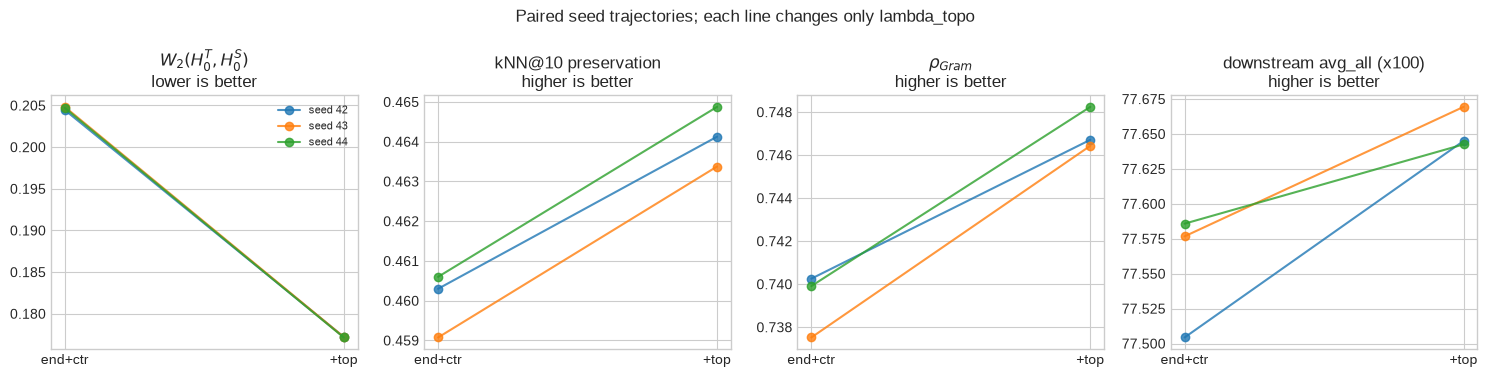

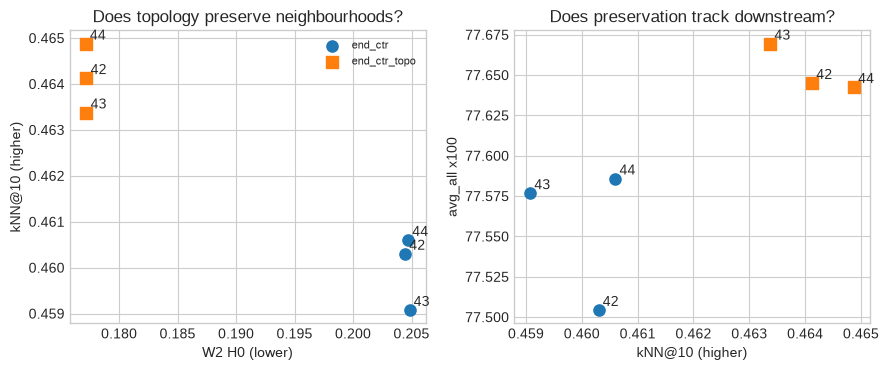

{
  "geometry_intended_all_3": true,
  "downstream_gain_all_3": true,
  "full_chain_all_3": true,
  "note": "Descriptive result over 3 paired seeds; consistency is not a causal significance test."
}


In [9]:
# 9. Paired deltas, consistency checks, descriptive association và plots.
from scipy.stats import spearmanr

BASELINE = "end_ctr"
TOPO = "end_ctr_topo"
METRICS = ["w2_h0", "knn_at_10", "rho_gram", "avg_all", "avg_iod", "avg_ood"]
DESIRED_SIGN = {"w2_h0": -1, "knn_at_10": 1, "rho_gram": 1, "avg_all": 1, "avg_iod": 1, "avg_ood": 1}

paired_rows = []
for seed in SEEDS:
    base = results[(results.seed == seed) & (results.variant == BASELINE)].iloc[0]
    topo = results[(results.seed == seed) & (results.variant == TOPO)].iloc[0]
    row = {"seed": seed}
    for metric in METRICS:
        row[f"{metric}_base"] = base[metric]
        row[f"{metric}_topo"] = topo[metric]
        row[f"delta_{metric}"] = topo[metric] - base[metric]
    paired_rows.append(row)
paired = pd.DataFrame(paired_rows)
paired.to_csv(RUN_ROOT / "paired_deltas.csv", index=False)

consistency_rows = []
for metric in METRICS:
    delta = paired[f"delta_{metric}"].dropna()
    desired = DESIRED_SIGN[metric]
    consistency_rows.append({
        "metric": metric,
        "desired": "decrease" if desired < 0 else "increase",
        "delta_mean": delta.mean(),
        "delta_std": delta.std(ddof=1),
        "n_desired_sign": int((desired * delta > 0).sum()),
        "n_pairs": len(delta),
        "consistent_all_3": bool(len(delta) == 3 and (desired * delta > 0).all()),
    })
consistency = pd.DataFrame(consistency_rows)
consistency.to_csv(RUN_ROOT / "consistency_summary.csv", index=False)

print("PAIRED DELTAS = topo - baseline")
display(paired.style.format(precision=5, na_rep="-"))
print("CONSISTENCY SUMMARY")
display(consistency.style.format(precision=5, na_rep="-"))

# Descriptive only: six runs are not six independent observations because runs are paired by seed.
association = pd.DataFrame([
    {"relation": "W2 vs kNN@10", "expected": "negative", "spearman": spearmanr(results.w2_h0, results.knn_at_10).statistic},
    {"relation": "W2 vs avg_all", "expected": "negative", "spearman": spearmanr(results.w2_h0, results.avg_all).statistic},
    {"relation": "kNN@10 vs avg_all", "expected": "positive", "spearman": spearmanr(results.knn_at_10, results.avg_all).statistic},
    {"relation": "rho_Gram vs avg_all", "expected": "positive", "spearman": spearmanr(results.rho_gram, results.avg_all).statistic},
])
association.to_csv(RUN_ROOT / "descriptive_associations.csv", index=False)
print("DESCRIPTIVE ASSOCIATIONS (n=6; do not read as causal/significance tests)")
display(association.style.format(precision=4))

plt.style.use("seaborn-v0_8-whitegrid")
plot_metrics = [
    ("w2_h0", r"$W_2(H_0^T,H_0^S)$", "lower is better"),
    ("knn_at_10", "kNN@10 preservation", "higher is better"),
    ("rho_gram", r"$\rho_{Gram}$", "higher is better"),
    ("avg_all", "downstream avg_all (x100)", "higher is better"),
]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, (metric, title, direction) in zip(axes, plot_metrics):
    for seed in SEEDS:
        sub = results[results.seed == seed].set_index("variant")
        y = [sub.loc[BASELINE, metric], sub.loc[TOPO, metric]]
        ax.plot([0, 1], y, marker="o", alpha=0.8, label=f"seed {seed}")
    ax.set(xticks=[0, 1], xticklabels=["end+ctr", "+top"], title=f"{title}\n{direction}")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Paired seed trajectories; each line changes only lambda_topo")
fig.tight_layout()
paired_plot = RUN_ROOT / "paired_seed_trajectories.png"
fig.savefig(paired_plot, dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for variant, marker in ((BASELINE, "o"), (TOPO, "s")):
    sub = results[results.variant == variant]
    axes[0].scatter(sub.w2_h0, sub.knn_at_10, marker=marker, s=65, label=variant)
    axes[1].scatter(sub.knn_at_10, sub.avg_all, marker=marker, s=65, label=variant)
    for _, row in sub.iterrows():
        axes[0].annotate(str(int(row.seed)), (row.w2_h0, row.knn_at_10), xytext=(3, 3), textcoords="offset points")
        axes[1].annotate(str(int(row.seed)), (row.knn_at_10, row.avg_all), xytext=(3, 3), textcoords="offset points")
axes[0].set(xlabel="W2 H0 (lower)", ylabel="kNN@10 (higher)", title="Does topology preserve neighbourhoods?")
axes[1].set(xlabel="kNN@10 (higher)", ylabel="avg_all x100", title="Does preservation track downstream?")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
chain_plot = RUN_ROOT / "geometry_downstream_chain.png"
fig.savefig(chain_plot, dpi=180, bbox_inches="tight")
plt.show()

checks = consistency.set_index("metric")["consistent_all_3"].to_dict()
verdict = {
    "geometry_intended_all_3": bool(checks["w2_h0"] and checks["knn_at_10"] and checks["rho_gram"]),
    "downstream_gain_all_3": bool(checks["avg_all"]),
    "full_chain_all_3": bool(checks["w2_h0"] and checks["knn_at_10"] and checks["rho_gram"] and checks["avg_all"]),
    "note": "Descriptive result over 3 paired seeds; consistency is not a causal significance test.",
}
(RUN_ROOT / "verdict.json").write_text(json.dumps(verdict, indent=2), encoding="utf-8")
print(json.dumps(verdict, indent=2))

In [10]:
# 10. Gói light artifacts (không gồm model/checkpoint/probe tensors); tải về nếu chạy trên Colab.
import zipfile

archive_path = RUN_ROOT.parent / f"{RUN_NAME}_summary.zip"
if MAKE_LIGHT_ARCHIVE:
    include_suffixes = {".csv", ".json", ".png", ".log"}
    with zipfile.ZipFile(archive_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for path in sorted(RUN_ROOT.rglob("*")):
            if path.is_file() and path.suffix.lower() in include_suffixes:
                zf.write(path, path.relative_to(RUN_ROOT))
    print(f"Created: {archive_path} ({archive_path.stat().st_size / 2**20:.1f} MiB)")
    if IN_COLAB and not SAVE_TO_GOOGLE_DRIVE:
        from google.colab import files
        files.download(str(archive_path))

Created: /content/embedding-kd/runs/topo_ablation_qwen3_0.6b_to_minilm_h384_100k_20260831-003049_summary.zip (1.2 MiB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>